# Validación del enfoque en Ecuaciones Diferenciales

## Objetivo

Este notebook replica y extiende el enfoque utilizado previamente en Métodos Numéricos, utilizando **Ecuaciones Diferenciales** como una segunda asignatura de análisis.

Se mantiene la misma pregunta general:

**¿Qué factores académicos disponibles después del primer parcial permiten estimar la probabilidad de que un estudiante alcance una firma final de 71 puntos o más?**

Para Ecuaciones Diferenciales se consideran como prerrequisitos directos:

- **Cálculo 2**
- **Álgebra Lineal**

Se compararán tres modelos:

1. **Modelo base:** utiliza únicamente el primer parcial.
2. **Modelo completo:** incorpora además carga académica, rendimiento previo y carrera.
3. **Modelo extendido:** agrega el rendimiento previo en Cálculo 2 y Álgebra Lineal.

No se incorporan prerrequisitos de segundo nivel en esta comparación.

## 1. Importación de librerías

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

## 2. Carga de los datos

Se utilizan los períodos 2024-2, 2025-1 y 2025-2.

- **2025-2:** contiene la cohorte objetivo de Ecuaciones Diferenciales.
- **2025-1:** se utiliza para construir el historial académico inmediato y recuperar los prerrequisitos directos.
- **2024-2:** se carga como parte del historial disponible, aunque no es necesario para los tres modelos comparados en esta prueba.

In [48]:
ruta_2024_2 = "../data/rendimiento_año_2024_ciclo_2_anon.xlsx"
ruta_2025_1 = "../data/rendimiento_año_2025_ciclo_1_anon.xlsx"
ruta_2025_2 = "../data/rendimiento_año_2025_ciclo_2_anon.xlsx"

df_2024_2 = pd.read_excel(ruta_2024_2)
df_2025_1 = pd.read_excel(ruta_2025_1)
df_2025_2 = pd.read_excel(ruta_2025_2)

print("2024-2:", df_2024_2.shape)
print("2025-1:", df_2025_1.shape)
print("2025-2:", df_2025_2.shape)

2024-2: (24468, 28)
2025-1: (19407, 29)
2025-2: (20420, 28)


## 3. Definición de la cohorte objetivo

La unidad de análisis es un estudiante que cursa **Ecuaciones Diferenciales en 2025-2**.

La variable objetivo `exonera` toma los valores:

- `1`: firma final mayor o igual a 71.
- `0`: firma final menor a 71.

In [49]:
ed_2025_2 = df_2025_2[
    df_2025_2["Asignatura"] == "ECUACIONES DIFERENCIALES"
].copy()

### Exclusión de estudiantes que ya cumplían el objetivo

Se excluyen los estudiantes que ya poseían una firma de 71 puntos o más
obtenida en un período anterior.

Para estos casos, el resultado que se desea predecir ya era conocido antes del
momento definido para realizar la predicción, por lo que mantenerlos en la
cohorte podría introducir información que no corresponde al problema planteado.

De esta manera, el análisis se limita a estudiantes que al inicio del período
todavía no habían alcanzado el umbral de 71 puntos.

In [50]:
cantidad_antes = len(ed_2025_2)

ed_2025_2 = ed_2025_2[
    ~(
        (ed_2025_2["Anho.Firma"] < 2025) &
        (ed_2025_2["Anho.Firma"] > 0) &
        (ed_2025_2["Firma"] >= 71)
    )
].copy()

cantidad_despues = len(ed_2025_2)

print("Estudiantes antes de la exclusión:", cantidad_antes)
print("Estudiantes después de la exclusión:", cantidad_despues)
print("Estudiantes excluidos:", cantidad_antes - cantidad_despues)

Estudiantes antes de la exclusión: 598
Estudiantes después de la exclusión: 572
Estudiantes excluidos: 26


In [51]:
ed_2025_2["exonera"] = (
    ed_2025_2["Firma"] >= 71
).astype(int)

print("Registros:", len(ed_2025_2))
print("Estudiantes únicos:", ed_2025_2["ALUMNO_ID"].nunique())

print("\nDistribución de la variable objetivo:")
print(ed_2025_2["exonera"].value_counts())

print("\nPorcentajes:")
print(
    (
        ed_2025_2["exonera"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Registros: 572
Estudiantes únicos: 572

Distribución de la variable objetivo:
exonera
0    434
1    138
Name: count, dtype: int64

Porcentajes:
exonera
0    75.87
1    24.13
Name: proportion, dtype: float64


## 4. Conversión de códigos de carrera

Los códigos de planes e intensificaciones se agrupan por carrera, al igual que en el análisis original.

In [52]:
career_code_mapping = {
    # Ingeniería Civil
    'CIV-PLS13': 'Ing. Civil',
    'CIV-PLS23': 'Ing. Civil',
    'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil',
    'INT9ORTERR': 'Ing. Civil',
    'INT9SANEHI': 'Ing. Civil',

    # Ingeniería Electromecánica
    'ELE-PLS13': 'Ing. Electromecánica',
    'ELE-PLS23': 'Ing. Electromecánica',
    'INT9ELECTR': 'Ing. Electromecánica',
    'INT9SDIGYT': 'Ing. Electromecánica',

    # Ingeniería Mecatrónica
    'MCT-PLS13': 'Ing. Mecatrónica',
    'MCT-PLS23': 'Ing. Mecatrónica',
    'MCT9-OPT': 'Ing. Mecatrónica',

    # Ingeniería Industrial
    'IND-PLS13': 'Ing. Industrial',
    'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial',
    'INT9-PROYT': 'Ing. Industrial',

    # Ingeniería Geográfica
    'CGF-PLS13': 'Ing. Geográfica',
    'CGF-PLS23': 'Ing. Geográfica',
    'INT9RNYMA': 'Ing. Geográfica',

    # Ingeniería Mecánica
    'MEC-PLS13': 'Ing. Mecánica',
    'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica',
    'MEC9-OPT': 'Ing. Mecánica',

    # Ingeniería Electrónica
    'ECA-PLS13': 'Ing. Electrónica',
    'ECA-PLS23': 'Ing. Electrónica',
    'ECA9-OPT': 'Ing. Electrónica'
}

ed_2025_2["carrera"] = (
    ed_2025_2["Cod.Car.Sec"]
    .astype(str)
    .str.strip()
    .map(career_code_mapping)
)

print("Códigos sin mapear:")
print(ed_2025_2.loc[ed_2025_2["carrera"].isna(), "Cod.Car.Sec"].value_counts())

print("\nDistribución por carrera:")
print(ed_2025_2["carrera"].value_counts())

Códigos sin mapear:
Series([], Name: count, dtype: int64)

Distribución por carrera:
carrera
Ing. Civil              258
Ing. Electromecánica    126
Ing. Industrial          60
Ing. Mecatrónica         52
Ing. Geográfica          40
Ing. Electrónica         24
Ing. Mecánica            12
Name: count, dtype: int64


## 5. Variables actuales

Se utiliza el primer parcial como información disponible en el momento de predicción.

La firma final se conserva únicamente para construir y verificar la variable objetivo; no se utiliza como predictor.

In [53]:
actual = ed_2025_2[
    [
        "ALUMNO_ID",
        "carrera",
        "Primer.Par",
        "Firma",
        "exonera"
    ]
].copy()

actual = actual.rename(
    columns={
        "Primer.Par": "primer_parcial",
        "Firma": "firma_actual"
    }
)

actual.head()

,ALUMNO_ID,carrera,primer_parcial,firma_actual,exonera
12861,FIUNA_ALUMNO_012948,Ing. Electrónica,4,2,0
12862,FIUNA_ALUMNO_012949,Ing. Electrónica,8,4,0
12863,FIUNA_ALUMNO_004541,Ing. Geográfica,30,19,0
12864,FIUNA_ALUMNO_004817,Ing. Geográfica,30,19,0
12865,FIUNA_ALUMNO_004550,Ing. Geográfica,45,39,0


## 6. Historial académico del ciclo anterior

A partir de 2025-1 se construyen:

- cantidad de materias cursadas;
- cantidad de materias aprobadas;
- tasa de aprobación.

Solo se utiliza información anterior a Ecuaciones Diferenciales 2025-2.

In [54]:
ids_ed = set(actual["ALUMNO_ID"])

historial_2025_1 = df_2025_1[
    df_2025_1["ALUMNO_ID"].isin(ids_ed)
].copy()

historial_2025_1["Aprobado_num"] = (
    historial_2025_1["Aprobado"]
    .map({"S": 1, "N": 0})
)

print(
    "Duplicados ALUMNO_ID + Cod.Asign:",
    historial_2025_1.duplicated(["ALUMNO_ID", "Cod.Asign"]).sum()
)

rendimiento_anterior = (
    historial_2025_1
    .groupby("ALUMNO_ID")
    .agg(
        cantidad_materias_anterior=("Cod.Asign", "nunique"),
        materias_aprobadas_anterior=("Aprobado_num", "sum")
    )
    .reset_index()
)

rendimiento_anterior["tasa_aprobacion_anterior"] = (
    rendimiento_anterior["materias_aprobadas_anterior"]
    / rendimiento_anterior["cantidad_materias_anterior"]
)

rendimiento_anterior.head()

Duplicados ALUMNO_ID + Cod.Asign: 0


,ALUMNO_ID,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior
0,FIUNA_ALUMNO_001404,5,3,0.6
1,FIUNA_ALUMNO_001888,5,4,0.8
2,FIUNA_ALUMNO_002612,5,4,0.8
3,FIUNA_ALUMNO_004255,5,3,0.6
4,FIUNA_ALUMNO_004541,1,1,1.0


## 7. Carga académica actual

Se calcula la cantidad de asignaturas diferentes cursadas por cada estudiante durante 2025-2.

In [55]:
carga_actual = (
    df_2025_2[
        df_2025_2["ALUMNO_ID"].isin(ids_ed)
    ]
    .groupby("ALUMNO_ID")["Cod.Asign"]
    .nunique()
    .reset_index(name="cantidad_materias_actual")
)

carga_actual.head()

,ALUMNO_ID,cantidad_materias_actual
0,FIUNA_ALUMNO_001404,3
1,FIUNA_ALUMNO_001888,6
2,FIUNA_ALUMNO_002612,6
3,FIUNA_ALUMNO_004255,3
4,FIUNA_ALUMNO_004541,4


## 8. Dataset general de Ecuaciones Diferenciales

Se integran las variables actuales con el historial académico.

In [56]:
dataset_general = (
    actual
    .merge(rendimiento_anterior, on="ALUMNO_ID", how="left")
    .merge(carga_actual, on="ALUMNO_ID", how="left")
)

print("Dimensiones:", dataset_general.shape)
print("\nValores faltantes:")
print(dataset_general.isnull().sum())

Dimensiones: (572, 9)

Valores faltantes:
ALUMNO_ID                      0
carrera                        0
primer_parcial                 0
firma_actual                   0
exonera                        0
cantidad_materias_anterior     8
materias_aprobadas_anterior    8
tasa_aprobacion_anterior       8
cantidad_materias_actual       0
dtype: int64


### Consideración sobre historial faltante

Una pequeña cantidad de estudiantes no posee registros en 2025-1. Estos casos se conservan en el dataset general, pero no podrán utilizarse en modelos que requieran las variables históricas sin aplicar una estrategia adicional de imputación.

Para la comparación con prerrequisitos esto no representa un problema, ya que el subconjunto con ambos prerrequisitos posee registros en 2025-1.

## 9. Identificación de los prerrequisitos directos

Los prerrequisitos directos utilizados son:

- **Cálculo 2**
- **Álgebra Lineal**

Ambos se buscan en 2025-1, es decir, antes del período objetivo.

In [57]:
calculo2 = df_2025_1[
    (df_2025_1["Asignatura"] == "CALCULO 2")
    & (df_2025_1["ALUMNO_ID"].isin(ids_ed))
].copy()

algebra_lineal = df_2025_1[
    (df_2025_1["Asignatura"] == "ALGEBRA LINEAL")
    & (df_2025_1["ALUMNO_ID"].isin(ids_ed))
].copy()

print("Cálculo 2:")
print("  Registros:", len(calculo2))
print("  Estudiantes únicos:", calculo2["ALUMNO_ID"].nunique())

print("\nÁlgebra Lineal:")
print("  Registros:", len(algebra_lineal))
print("  Estudiantes únicos:", algebra_lineal["ALUMNO_ID"].nunique())

Cálculo 2:
  Registros: 292
  Estudiantes únicos: 292

Álgebra Lineal:
  Registros: 342
  Estudiantes únicos: 342


## 10. Construcción de las features de prerrequisitos

En 2025-1 existe `FirmaCalculada`, que representa el rendimiento calculado en el período.

Como un estudiante puede conservar una firma anterior o mejorarla durante el semestre, se define la firma disponible al finalizar 2025-1 como el máximo entre `Firma` y `FirmaCalculada`.

También se utiliza la variable `Aprobado` como indicador adicional del resultado en el prerrequisito.

In [58]:
def construir_feature_prerrequisito(df, prefijo):
    temp = df.copy()

    temp[f"firma_{prefijo}"] = temp[
        ["Firma", "FirmaCalculada"]
    ].max(axis=1)

    temp[f"aprobo_{prefijo}"] = (
        temp["Aprobado"]
        .map({"S": 1, "N": 0})
    )

    return temp[
        [
            "ALUMNO_ID",
            f"firma_{prefijo}",
            f"aprobo_{prefijo}"
        ]
    ].copy()

features_calculo2 = construir_feature_prerrequisito(
    calculo2,
    "calculo2"
)

features_algebra_lineal = construir_feature_prerrequisito(
    algebra_lineal,
    "algebra_lineal"
)

features_calculo2.head()

,ALUMNO_ID,firma_calculo2,aprobo_calculo2
11214,FIUNA_ALUMNO_001404,60,0
11215,FIUNA_ALUMNO_004255,60,0
11218,FIUNA_ALUMNO_005963,36,1
11219,FIUNA_ALUMNO_007449,36,1
11234,FIUNA_ALUMNO_009668,67,1


## 11. Cobertura de los prerrequisitos

Se revisa cuántos estudiantes poseen información de cada prerrequisito y cuántos disponen de ambos.

In [59]:
ids_calculo2 = set(features_calculo2["ALUMNO_ID"])
ids_algebra = set(features_algebra_lineal["ALUMNO_ID"])
ids_ambos = ids_calculo2.intersection(ids_algebra)

print("Cohorte total:", len(ids_ed))
print("Con Cálculo 2:", len(ids_calculo2))
print("Con Álgebra Lineal:", len(ids_algebra))
print("Con ambos prerrequisitos:", len(ids_ambos))
print(
    "Cobertura con ambos:",
    round(len(ids_ambos) / len(ids_ed) * 100, 2),
    "%"
)

Cohorte total: 572
Con Cálculo 2: 292
Con Álgebra Lineal: 342
Con ambos prerrequisitos: 236
Cobertura con ambos: 41.26 %


## 12. Incorporación de los prerrequisitos

Se realiza un `left join` para conservar la cohorte completa y posteriormente se selecciona el subconjunto con información de ambos prerrequisitos.

La comparación de los tres modelos se realizará sobre **exactamente los mismos estudiantes**.

In [60]:
dataset_extension = (
    dataset_general
    .merge(features_calculo2, on="ALUMNO_ID", how="left")
    .merge(features_algebra_lineal, on="ALUMNO_ID", how="left")
)

dataset_prerrequisitos = dataset_extension.dropna(
    subset=[
        "cantidad_materias_anterior",
        "tasa_aprobacion_anterior",
        "firma_calculo2",
        "aprobo_calculo2",
        "firma_algebra_lineal",
        "aprobo_algebra_lineal"
    ]
).copy()

print("Dataset completo:", dataset_extension.shape)
print("Subconjunto con ambos prerrequisitos:", dataset_prerrequisitos.shape)

print("\nDistribución de exonera en el subconjunto:")
print(dataset_prerrequisitos["exonera"].value_counts())

print("\nPorcentajes:")
print(
    (dataset_prerrequisitos["exonera"]
     .value_counts(normalize=True) * 100)
    .round(2)
)

Dataset completo: (572, 13)
Subconjunto con ambos prerrequisitos: (236, 13)

Distribución de exonera en el subconjunto:
exonera
0    134
1    102
Name: count, dtype: int64

Porcentajes:
exonera
0    56.78
1    43.22
Name: proportion, dtype: float64


### Observación

El subconjunto con ambos prerrequisitos presenta una distribución suficientemente equilibrada para comparar los modelos de clasificación.

## 13. Análisis descriptivo de los prerrequisitos

Se comparan las firmas de Cálculo 2 y Álgebra Lineal según el resultado posterior en Ecuaciones Diferenciales.

In [61]:
dataset_prerrequisitos.groupby("exonera")[
    [
        "firma_calculo2",
        "firma_algebra_lineal"
    ]
].agg(["mean", "median", "std"]).round(2)

firma_calculo2               firma_algebra_lineal              
                  mean median    std                 mean median    std
exonera                                                                
0                62.09   60.0   9.96                59.72   58.0  10.10
1                70.98   71.0  11.33                74.51   76.0  11.65

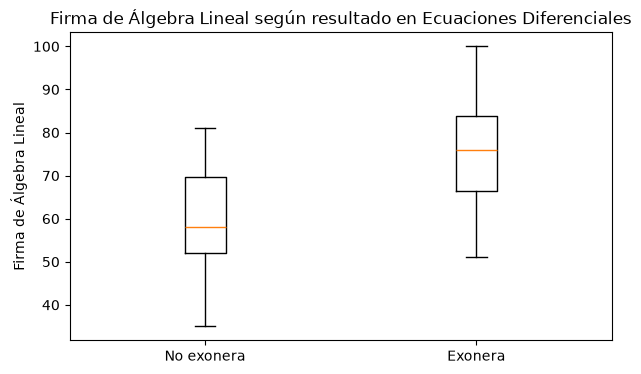

In [62]:
fig, ax = plt.subplots(figsize=(7, 4))

datos = [
    dataset_prerrequisitos.loc[
        dataset_prerrequisitos["exonera"] == 0,
        "firma_algebra_lineal"
    ],
    dataset_prerrequisitos.loc[
        dataset_prerrequisitos["exonera"] == 1,
        "firma_algebra_lineal"
    ]
]

ax.boxplot(
    datos,
    tick_labels=["No exonera", "Exonera"]
)
ax.set_title("Firma de Álgebra Lineal según resultado en Ecuaciones Diferenciales")
ax.set_ylabel("Firma de Álgebra Lineal")
plt.show()

## 14. Definición de los tres modelos

### Modelo base
Utiliza únicamente:
- primer parcial.

### Modelo completo
Agrega:
- cantidad de materias actuales;
- cantidad de materias del ciclo anterior;
- tasa de aprobación anterior;
- carrera.

### Modelo extendido
Agrega al modelo completo:
- firma de Cálculo 2;
- aprobación de Cálculo 2;
- firma de Álgebra Lineal;
- aprobación de Álgebra Lineal.

In [63]:
variables_base = [
    "primer_parcial"
]

variables_completas = [
    "primer_parcial",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior",
    "carrera"
]

variables_extendidas = variables_completas + [
    "firma_calculo2",
    "aprobo_calculo2",
    "firma_algebra_lineal",
    "aprobo_algebra_lineal"
]

numericas_base = [
    "primer_parcial"
]

numericas_completas = [
    "primer_parcial",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior"
]

numericas_extendidas = numericas_completas + [
    "firma_calculo2",
    "aprobo_calculo2",
    "firma_algebra_lineal",
    "aprobo_algebra_lineal"
]

categoricas = ["carrera"]

X_base = dataset_prerrequisitos[variables_base]
X_completo = dataset_prerrequisitos[variables_completas]
X_extendido = dataset_prerrequisitos[variables_extendidas]
y = dataset_prerrequisitos["exonera"]

## 15. División entrenamiento/prueba

Se utiliza una única partición estratificada para los tres modelos.

In [64]:
train_idx, test_idx = train_test_split(
    dataset_prerrequisitos.index,
    test_size=0.25,
    random_state=42,
    stratify=y
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Entrenamiento:", len(train_idx))
print("Prueba:", len(test_idx))
print("\nDistribución en prueba:")
print(y_test.value_counts())

Entrenamiento: 177
Prueba: 59

Distribución en prueba:
exonera
0    33
1    26
Name: count, dtype: int64


## 16. Construcción de pipelines

Las variables numéricas se estandarizan y la carrera se transforma mediante One-Hot Encoding.

El modelo utilizado es Regresión Logística.

In [65]:
def crear_modelo_logistico(variables_numericas, incluir_carrera=False):
    transformadores = [
        (
            "num",
            StandardScaler(),
            variables_numericas
        )
    ]

    if incluir_carrera:
        transformadores.append(
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ),
                categoricas
            )
        )

    preprocesador = ColumnTransformer(
        transformers=transformadores
    )

    return Pipeline(
        steps=[
            ("preprocesamiento", preprocesador),
            (
                "modelo",
                LogisticRegression(
                    random_state=42,
                    max_iter=1000
                )
            )
        ]
    )

modelo_base = crear_modelo_logistico(
    numericas_base,
    incluir_carrera=False
)

modelo_completo = crear_modelo_logistico(
    numericas_completas,
    incluir_carrera=True
)

modelo_extendido = crear_modelo_logistico(
    numericas_extendidas,
    incluir_carrera=True
)

In [66]:
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test, y_prob
        )
    }

    return resultados, y_pred

## 17. Entrenamiento y evaluación en test

In [67]:
datos_modelos = [
    (
        "Modelo base",
        modelo_base,
        X_base
    ),
    (
        "Modelo completo",
        modelo_completo,
        X_completo
    ),
    (
        "Modelo extendido",
        modelo_extendido,
        X_extendido
    )
]

resultados_test = {}
predicciones_test = {}

for nombre, modelo, X in datos_modelos:
    modelo.fit(
        X.loc[train_idx],
        y_train
    )

    resultados, predicciones = evaluar_modelo(
        modelo,
        X.loc[test_idx],
        y_test
    )

    resultados_test[nombre] = resultados
    predicciones_test[nombre] = predicciones

comparacion_test = (
    pd.DataFrame(resultados_test)
    .T
)

comparacion_test.round(3)

,accuracy,precision,recall,f1,roc_auc
Modelo base,0.966,1.000,0.923,0.960,0.980
Modelo completo,0.898,0.917,0.846,0.880,0.945
Modelo extendido,0.881,0.913,0.808,0.857,0.946


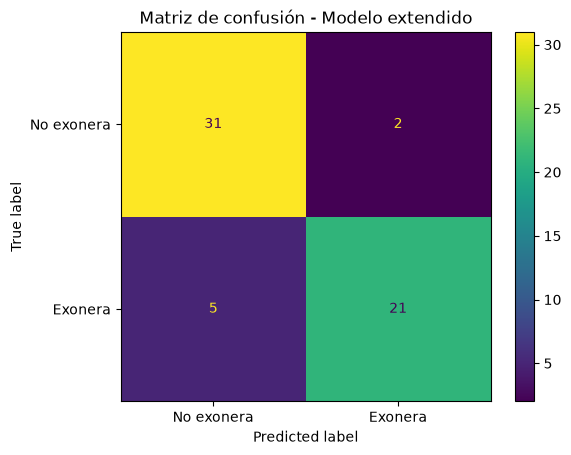

In [68]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test["Modelo extendido"],
    display_labels=["No exonera", "Exonera"]
)

plt.title("Matriz de confusión - Modelo extendido")
plt.show()

## 18. Validación cruzada estratificada

Para obtener una evaluación más robusta se utiliza validación cruzada estratificada de 5 folds.

Los mismos folds se utilizan en los tres modelos.

In [69]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

resultados_cv = {}

for nombre, modelo, X in datos_modelos:
    cv_resultado = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring=metricas
    )

    resultados_cv[nombre] = pd.DataFrame({
        metrica: cv_resultado[f"test_{metrica}"]
        for metrica in metricas
    })

resumen_cv = pd.DataFrame(
    {
        f"{nombre} - Media": resultado.mean()
        for nombre, resultado in resultados_cv.items()
    }
).T

desviaciones_cv = pd.DataFrame(
    {
        f"{nombre} - Desv.": resultado.std()
        for nombre, resultado in resultados_cv.items()
    }
).T

print("Medias:")
display(resumen_cv.round(3))

print("\nDesviaciones estándar:")
display(desviaciones_cv.round(3))

Medias:


,accuracy,precision,recall,f1,roc_auc
Modelo base - Media,0.890,0.897,0.862,0.874,0.951
Modelo completo - Media,0.894,0.901,0.863,0.875,0.952
Modelo extendido - Media,0.928,0.932,0.903,0.915,0.955



Desviaciones estándar:


,accuracy,precision,recall,f1,roc_auc
Modelo base - Desv.,0.061,0.119,0.064,0.058,0.047
Modelo completo - Desv.,0.040,0.090,0.104,0.048,0.044
Modelo extendido - Desv.,0.063,0.078,0.089,0.074,0.041


## 19. Aporte incremental de los prerrequisitos

Se calcula la diferencia entre el modelo extendido y el modelo completo.

Una diferencia positiva indica que incorporar Cálculo 2 y Álgebra Lineal mejoró esa métrica.

In [70]:
mejora_prerrequisitos = (
    resultados_cv["Modelo extendido"].mean()
    - resultados_cv["Modelo completo"].mean()
)

pd.DataFrame(
    mejora_prerrequisitos,
    columns=[
        "Diferencia extendido - completo"
    ]
).round(3)

,Diferencia extendido - completo
accuracy,0.034
precision,0.031
recall,0.040
f1,0.041
roc_auc,0.003


## 20. Conclusiones

La validación en Ecuaciones Diferenciales muestra nuevamente que el **primer parcial**
posee una capacidad predictiva importante para anticipar si un estudiante alcanzará
una firma de 71 puntos o más.

El modelo completo, que incorpora información académica general además del primer
parcial, presenta un rendimiento promedio similar al modelo base. Esto indica que,
para esta cohorte, el primer parcial por sí solo concentra una parte importante de
la información predictiva.

Sin embargo, al incorporar el rendimiento previo en los prerrequisitos directos
**Cálculo 2** y **Álgebra Lineal**, el modelo extendido mejora de manera más clara.

En validación cruzada estratificada, el modelo extendido obtuvo aproximadamente:

- Accuracy: 0.928
- Precision: 0.932
- Recall: 0.903
- F1-score: 0.915
- ROC-AUC: 0.955

Respecto al modelo completo, la incorporación de los prerrequisitos produjo mejoras
de aproximadamente 0.03 a 0.04 en Accuracy, Precision, Recall y F1-score.

Esto sugiere que el desempeño previo en Cálculo 2 y Álgebra Lineal aporta información
complementaria relevante para estimar el rendimiento posterior en Ecuaciones
Diferenciales.

El primer parcial continúa siendo una fuente importante de información, pero los
resultados muestran que conocer el desempeño en asignaturas prerrequisito puede
mejorar la capacidad de clasificación del modelo.

Esta segunda materia también permite comprobar que el enfoque desarrollado
inicialmente para Métodos Numéricos puede replicarse en otra asignatura y que la
incorporación de información académica previa puede aportar valor predictivo.

### Limitaciones

- La comparación de los tres modelos se realiza únicamente con los estudiantes que poseen información de ambos prerrequisitos.
- La disponibilidad de datos históricos depende de los períodos incluidos en los archivos.
- Las asociaciones observadas no deben interpretarse como relaciones causales.
- Los resultados corresponden a las cohortes analizadas y deberían validarse con nuevos períodos antes de generalizarse.